# Bevölkerungsraster der Steiermark

Deskriptive Analyse der 100-m-Bevölkerungsraster 2019 und 2025, ihrer zeitlichen Rückrechnung und der harmonisierten Gemeindegeometrie.

**Quellen:** `OGD/Popreg_100m/population_grid_styria_2019.geoparquet`, `OGD/Popreg_100m/population_grid_styria_2025.geoparquet`, `ANAL/data/raster_100m_styria.geoparquet`, `OGD/STMK_POP_2002_2025.csv`, `ANAL/data/firms_assigned_100m.geoparquet` und die historisierten Gemeindegrenzen von Statistik Austria.

In [1]:
import os
import sys
from pathlib import Path
os.chdir(r"D:\CO2_Masterarbeit\CO2_Masterarbeit")
sys.path.insert(0, r"D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG")
sys.path.insert(0, r"D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG\Population_Grid_Styria")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from plotting.apa7 import set_apa7_style, new_figure, save_apa7, HIST_KWARGS
import population_grid_visualizations as pgv

set_apa7_style()

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "FIG" / "Population_Grid_Styria"

In [2]:
data = pgv.load_inputs(PROJECT_DIR)
population = data["population_2025"]
for year in (2019, 2025):
    layer = data[f"population_{year}"]
    print(f"Bewohnte 100-m-Zellen {year}: {len(layer):,}; Rasterbevölkerung: {layer['population'].sum():,.0f}")
print(f"Vollständiges steirisches Rasteruniversum: {len(data['raster_table']):,}")
print(f"Gemeinden im harmonisierten Gebietsstand 2025: {len(data['municipalities']):,}")
population["population"].describe()

Bewohnte 100-m-Zellen 2019: 121,992; Rasterbevölkerung: 1,243,846
Bewohnte 100-m-Zellen 2025: 123,403; Rasterbevölkerung: 1,272,478
Vollständiges steirisches Rasteruniversum: 1,641,447
Gemeinden im harmonisierten Gebietsstand 2025: 285


count    123403.000000
mean         10.311565
std          20.483222
min           1.000000
25%           3.000000
50%           5.000000
75%          10.000000
max         584.000000
Name: population, dtype: float64

## Der Raster selbst

### Bevölkerung je bewohnter 100-m-Zelle

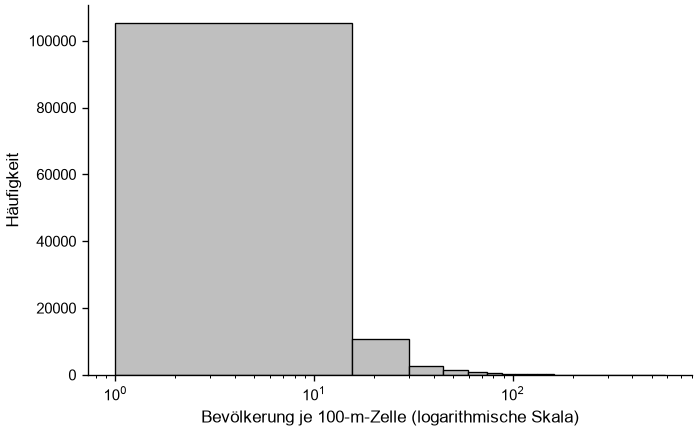

In [3]:
fig, ax = new_figure()
ax.hist(population["population"], bins=40, **HIST_KWARGS)
ax.set_xscale("log")
ax.set(xlabel="Bevölkerung je 100-m-Zelle (logarithmische Skala)", ylabel="Häufigkeit")
save_apa7(fig, "FIG/Population_Grid_Styria/figure_1_population_per_cell.png")
save_apa7(fig, "FIG/Population_Grid_Styria/figure_1_population_per_cell.svg")
plt.show()

### Übersichtskarte: Bevölkerung im 100-m-Raster

Die logarithmische Farbskala macht sowohl die Konzentration im Grazer Zentralraum als auch dünn besiedelte Zellen sichtbar.

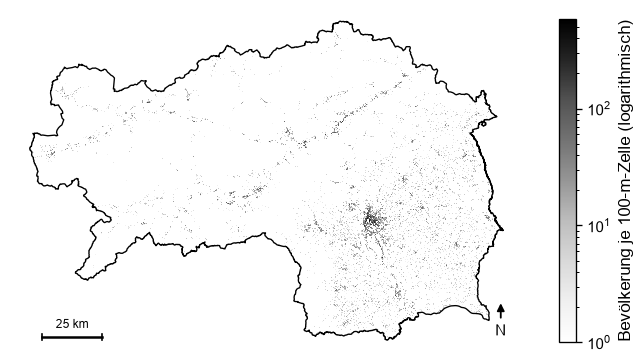

In [4]:
pgv.plot_population_overview(data, OUTPUT_DIR)

### Drei Siedlungstypen im gleichen Maßstab

Die jeweils 6 × 6 km großen Ausschnitte zeigen, was die räumliche Auflösung in Graz, Leoben und einer ländlichen Streusiedlung bei Eibiswald erfasst.

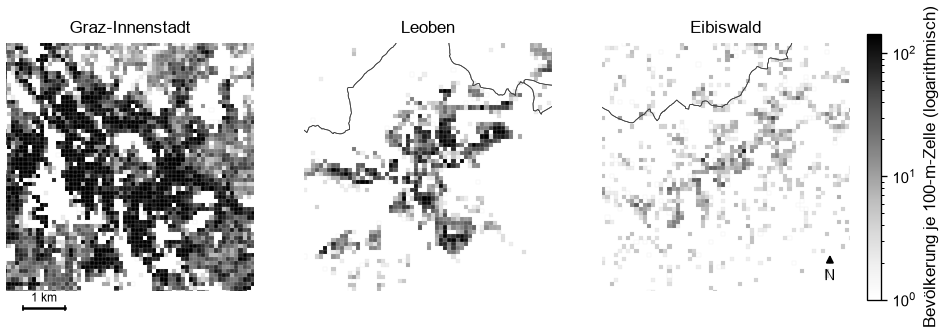

In [5]:
pgv.plot_equal_scale_details(data, OUTPUT_DIR)

### Alternative Farbskalierung

Abbildung 3a verwendet die logarithmische Viridis-Farbskala von Violett über Blau bis Grün und den vollständigen Wertebereich der Rasterbevölkerung.

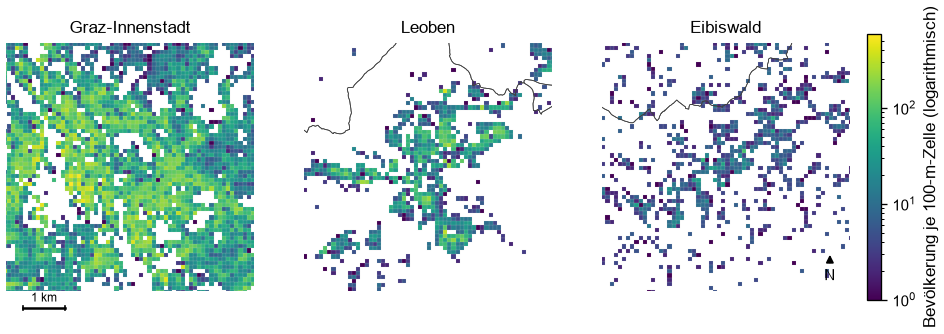

In [6]:
pgv.plot_equal_scale_details_figure_3a(data, OUTPUT_DIR)

### Alternative mit Verwaltungsgrundkarte

Abbildung 3b legt das Bevölkerungsraster aus Abbildung 3a über die graue Verwaltungsgrundkarte von [basemap.at](https://basemap.at/) (CC BY 4.0).

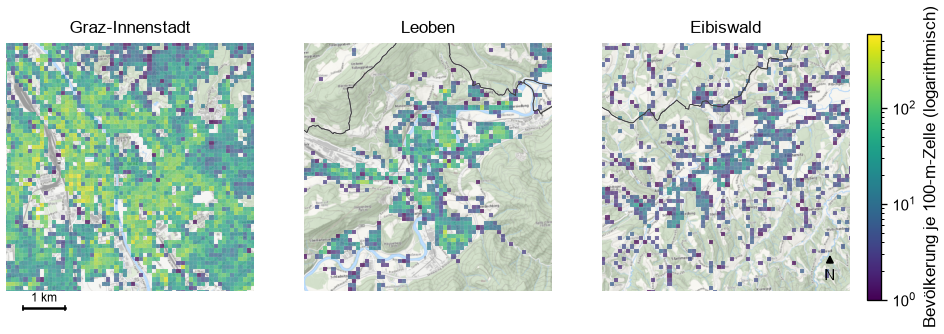

In [7]:
pgv.plot_equal_scale_details_figure_3b(data, OUTPUT_DIR)

### Konzentration der Rasterbevölkerung

Die Kurve ordnet bewohnte Zellen absteigend nach ihrer Bevölkerung. Damit lässt sich die räumliche Konzentration direkt quantifizieren.

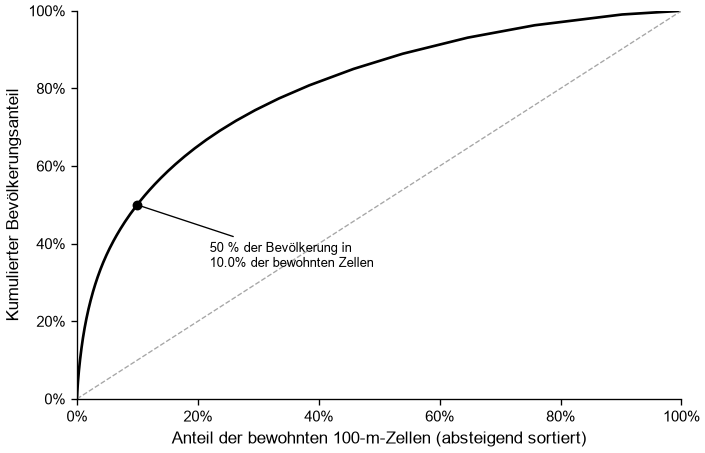

population_share,minimum_share_of_populated_cells
0.500000,0.099536
0.800000,0.372195
0.900000,0.566291


In [8]:
concentration_summary = pgv.plot_concentration_curve(data, OUTPUT_DIR)
display(concentration_summary.style.format({"Anteil der Zellen (%)": "{:.1f}", "Kumulierter Bevölkerungsanteil (%)": "{:.0f}"}).hide(axis="index"))

### Räumliche Risikomenge

Gezeigt werden alle Zellen mit Bevölkerung, Firmenbestand oder beiden Merkmalen. Die Schnittmenge bildet den direkt beobachtbaren räumlichen Kontaktbereich beider Datensätze.

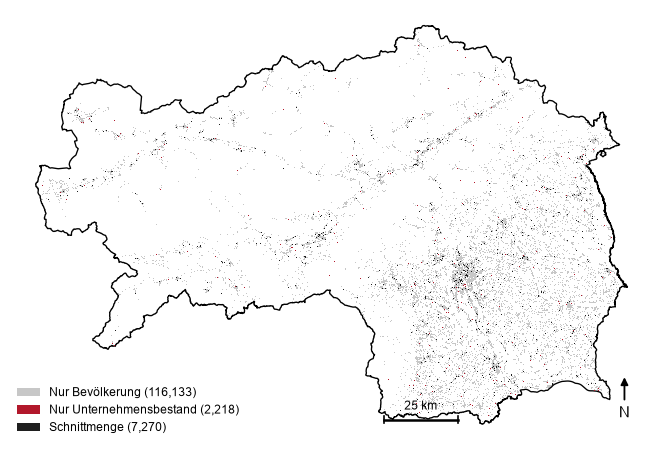

Kategorie,Zellen
Nur Bevölkerung,"116,133"
Nur Unternehmensbestand,"2,218"
Schnittmenge,"7,270"


In [9]:
risk_summary = pgv.plot_risk_set_map(data, OUTPUT_DIR)
display(risk_summary.rename(columns={"risk_category": "Kategorie", "cells": "Zellen"}).style.format({"Zellen": "{:,.0f}"}).hide(axis="index"))

### Raster versus Gemeindeaggregat

Dasselbe Grazer Fenster wird einmal im 100-m-Raster und einmal als Gemeindeaggregat gezeigt. Der Vergleich visualisiert den Informationsverlust durch administrative Aggregation (MAUP/Openshaw-Problem).

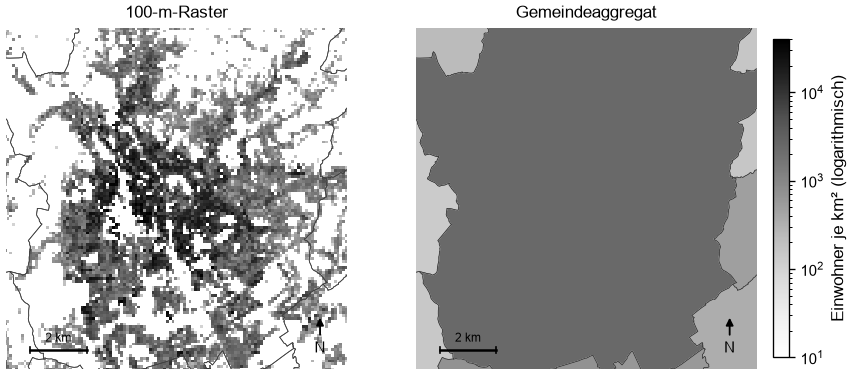

In [10]:
pgv.plot_raster_vs_municipality(data, OUTPUT_DIR)

## Rückrechnung

Die Rückrechnung verwendet zwei beobachtete kleinräumige Verteilungen: 2015–2019 werden aus dem Raster 2019, 2020–2025 aus dem Raster 2025 gemeindeweise skaliert. Das jeweilige Jahresniveau entspricht der amtlichen Gemeindebevölkerung; innerhalb jeder Gemeinde bleibt die räumliche Verteilung des jeweiligen Ankerjahres proportional erhalten.

### Ablauf der Rückrechnung

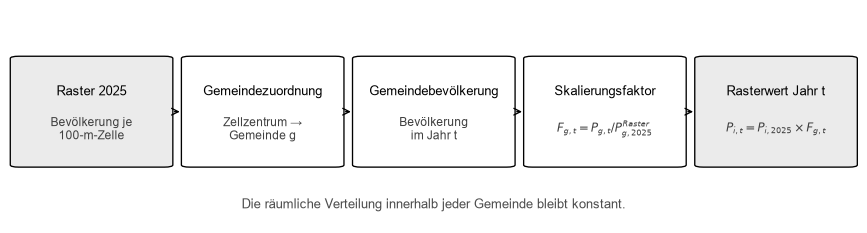

In [11]:
pgv.plot_backcast_workflow(OUTPUT_DIR)

### Indexierte Gemeindebevölkerung (2015 = 100)

Einzellinien zeigen die Streuung zwischen Gemeinden; Median und Interquartilsbereich fassen die zentrale Entwicklung zusammen.

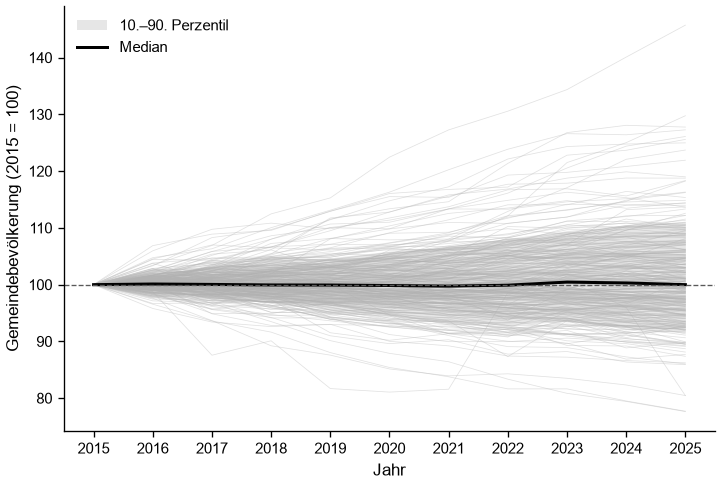

In [12]:
pgv.plot_indexed_municipal_trends(data, OUTPUT_DIR)

### Beschriftete Extremverläufe der Gemeindebevölkerung

Ergänzend werden die fünf stärksten Zunahmen und die fünf stärksten Abnahmen von 2015 bis 2025 hervorgehoben. Die Linienbeschriftungen stehen rechts außerhalb der Zeichenfläche.

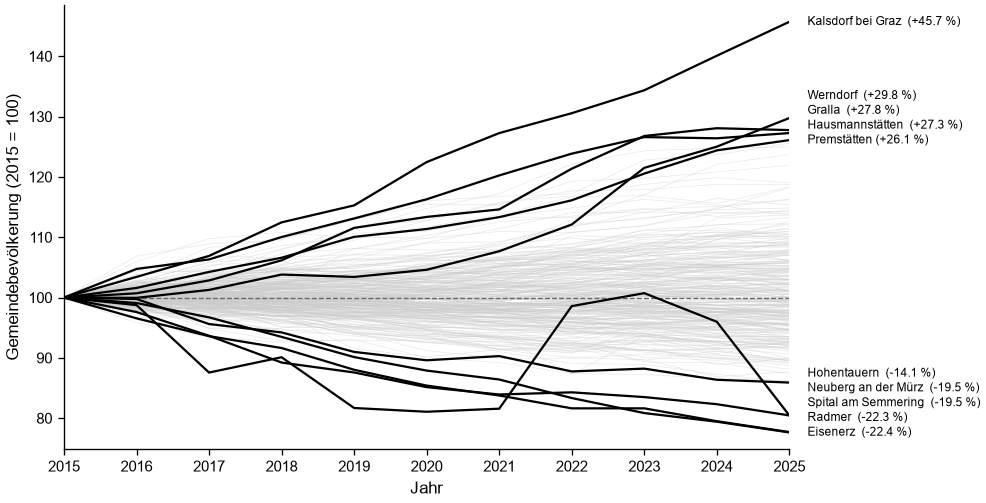

Gemeindecode,Gemeinde,Veränderung 2015–2025 (%),Gruppe
60624,Kalsdorf bei Graz,+45.7,Stärkste Zunahme
60655,Werndorf,+29.8,Stärkste Zunahme
61012,Gralla,+27.8,Stärkste Zunahme
60619,Hausmannstätten,+27.3,Stärkste Zunahme
60670,Premstätten,+26.1,Stärkste Zunahme
62010,Hohentauern,-14.1,Stärkste Abnahme
62144,Neuberg an der Mürz,-19.5,Stärkste Abnahme
62131,Spital am Semmering,-19.5,Stärkste Abnahme
61112,Radmer,-22.3,Stärkste Abnahme
61101,Eisenerz,-22.4,Stärkste Abnahme


In [13]:
municipal_extremes = pgv.plot_indexed_municipal_trends_labelled(data, OUTPUT_DIR)
display(municipal_extremes.rename(columns={"LAU_CODE": "Gemeindecode", "LAU_NAME": "Gemeinde", "change_2015_2025_pct": "Veränderung 2015–2025 (%)", "group": "Gruppe"}).style.format({"Veränderung 2015–2025 (%)": "{:+.1f}"}).hide(axis="index"))

In [14]:
def get_gemeinde_population(data, gemeinde_name):
    """Return all available yearly population values for a municipality."""
    metrics = data["municipal_metrics"]

    matches = metrics.loc[
        metrics["LAU_NAME"].astype(str).str.strip().str.casefold()
        == gemeinde_name.strip().casefold()
    ]

    if matches.empty:
        raise ValueError(f"Gemeinde nicht gefunden: {gemeinde_name!r}")
    if len(matches) > 1:
        raise ValueError(f"Gemeindename ist nicht eindeutig: {gemeinde_name!r}")

    population_columns = sorted(
        (
            column
            for column in metrics.columns
            if column.startswith("POP_") and column[4:].isdigit()
        ),
        key=lambda column: int(column[4:]),
    )

    return pd.DataFrame({
        "year": [int(column[4:]) for column in population_columns],
        "population": matches.iloc[0][population_columns].to_numpy(),
    })

get_gemeinde_population(data, "Spital am Semmering")

,year,population
0,2002,1834
1,2003,1785
2,2004,1754
3,2005,1738
4,2006,1707
5,2007,1665
6,2008,1669
7,2009,1669
8,2010,1613
9,2011,1596


### Skalierungsfaktoren nach Jahr

Die Verteilungen zeigen, wie stark die Rückrechnung mit wachsendem Abstand vom Referenzjahr 2025 eingreift.

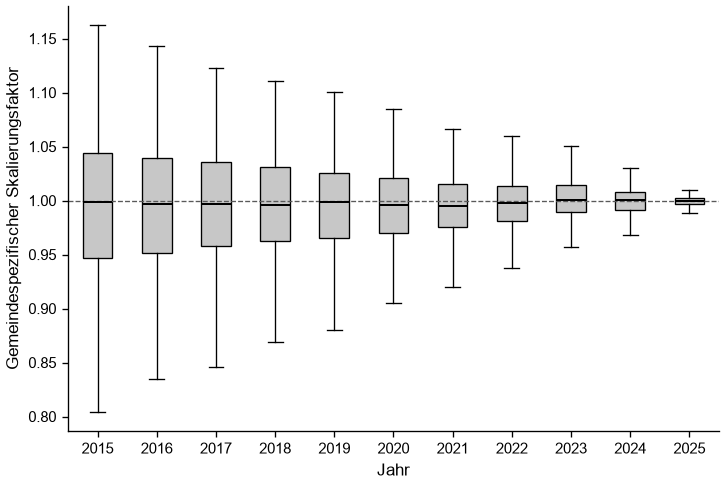

In [15]:
pgv.plot_scaling_factor_boxplots(data, OUTPUT_DIR)

### Gemeindewachstum 2015–2025

Die flächenkonstante Färbung innerhalb jeder Gemeinde macht zugleich die zentrale Limitation der Rückrechnung sichtbar: Innergemeindliche Verschiebungen werden nicht modelliert.

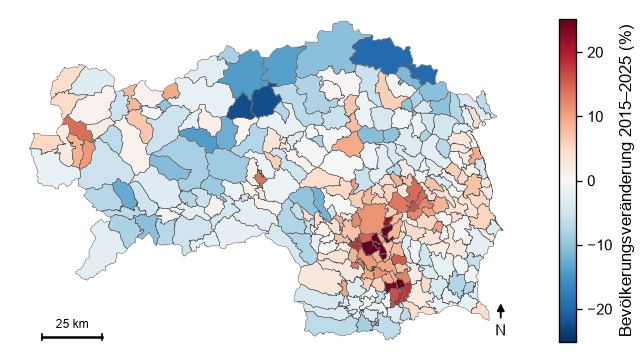

In [16]:
pgv.plot_municipal_growth_map(data, OUTPUT_DIR)

## Vergleich der Bevölkerungsraster 2019 und 2025

### Abbildung 10b: Räumliche Verteilung im direkten Vergleich

Beide Karten verwenden dieselbe logarithmische Bevölkerungsskala und eine gemeinsame Maßstabsleiste. Auf einen Nordpfeil wird bewusst verzichtet.

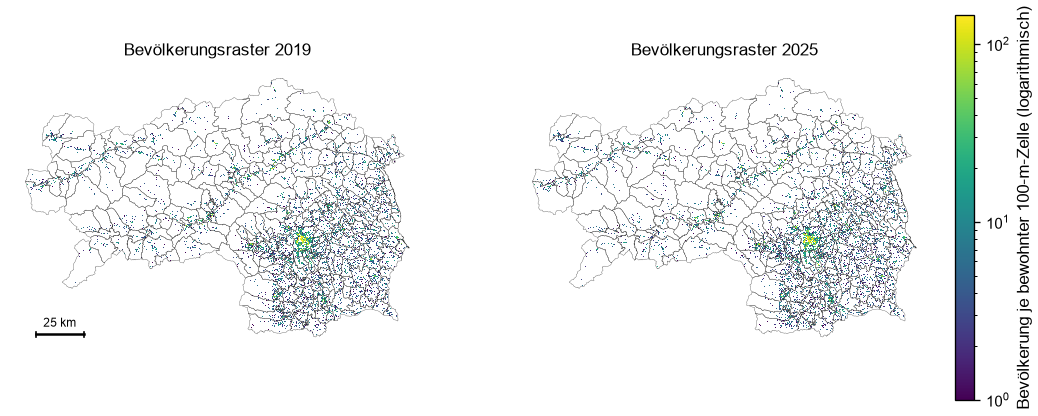

Kategorie,Zellen
Nur 2019 besiedelt,"4,654"
2025 neu besiedelt,"6,065"
In beiden Jahren besiedelt,"117,338"


In [17]:
cell_comparison_summary = pgv.plot_population_year_comparison(data, OUTPUT_DIR)
display(cell_comparison_summary.style.format({"Zellen": "{:,.0f}"}).hide(axis="index"))

### Abbildung 11: Im Jahr 2025 neu besiedelte Zellen

Rot markiert sind 100-m-Zellen, die im POPREG-Raster 2025 Bevölkerung aufweisen, im Raster 2019 jedoch nicht enthalten waren. Grau zeigt das räumliche Siedlungsmuster 2025 als Kontext. Die Verwaltungsgrundkarte stammt von [basemap.at](https://basemap.at/) (CC BY 4.0). Legende und Maßstab stehen außerhalb der Kartenfläche; die Abbildung enthält gemäß der verwendeten APA-7-Gestaltung keinen internen Titel.

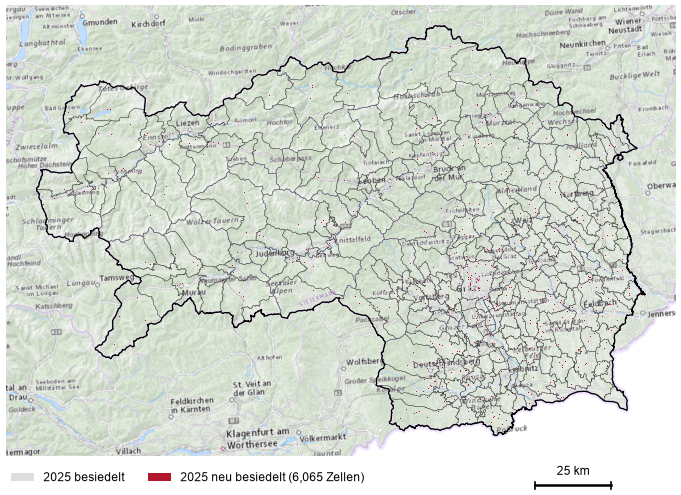

2025 neu besiedelte Zellen in der Steiermark: 6,065


In [18]:
new_cells_styria = pgv.plot_newly_populated_cells_styria(data, OUTPUT_DIR)
print(f"2025 neu besiedelte Zellen in der Steiermark: {new_cells_styria:,}")

### Abbildung 11b: Detailausschnitt Graz

Der 16 × 16 km große Ausschnitt zeigt die 2025 neu besiedelten Zellen im Grazer Zentralraum bei unveränderter 100-m-Auflösung auf der grauen Verwaltungsgrundkarte von [basemap.at](https://basemap.at/) (CC BY 4.0). Legende und Maßstab stehen außerhalb der Kartenfläche; ein interner Titel entfällt.

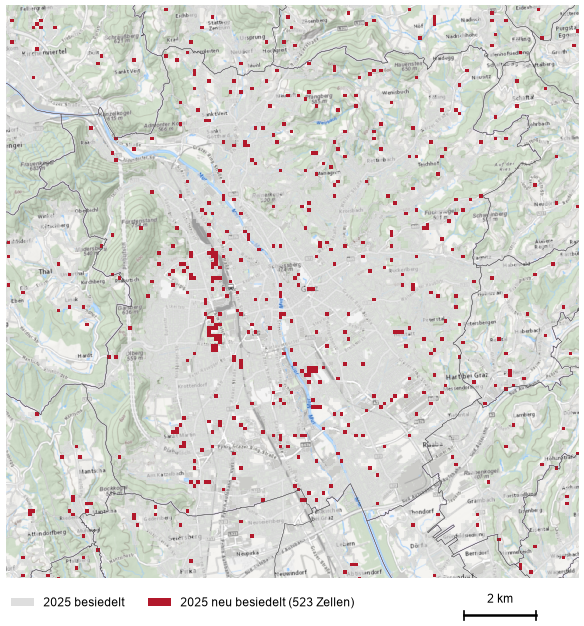

2025 neu besiedelte Zellen im Grazer Kartenausschnitt: 523


In [19]:
new_cells_graz = pgv.plot_newly_populated_cells_graz(data, OUTPUT_DIR)
print(f"2025 neu besiedelte Zellen im Grazer Kartenausschnitt: {new_cells_graz:,}")

### Abbildung 11c: Bevölkerung in den neu besiedelten Zellen

Der Kartenausschnitt entspricht Abbildung 11b. Die 2025 neu besiedelten 100-m-Zellen werden nun nach ihrer Bevölkerung 2025 auf einer logarithmischen Farbskala dargestellt. Die graue Verwaltungsgrundkarte stammt von [basemap.at](https://basemap.at/) (CC BY 4.0). Legende und Maßstab stehen außerhalb der Kartenfläche; ein interner Titel entfällt.

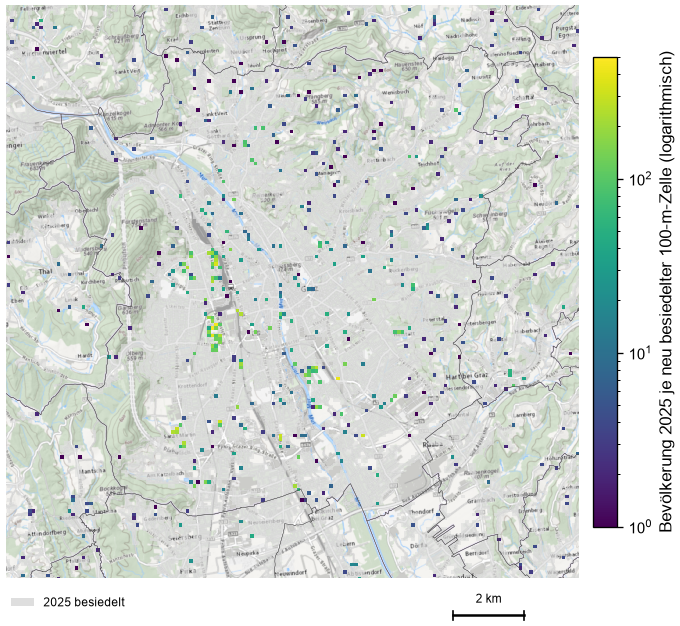

,Wert
Zellen,523.0
Bevölkerung insgesamt,"19,515.0"
Median je Zelle,6.0
Maximum je Zelle,502.0


In [20]:
new_cells_graz_population = pgv.plot_newly_populated_cells_graz_by_population(data, OUTPUT_DIR)
display(new_cells_graz_population.to_frame("Wert").style.format({"Wert": "{:,.1f}"}))